In [1]:
import dill; dill.load_session('checkpoint.pkl')

## 1. Imports

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

## 2. Configuración

In [2]:
np.random.seed(42)
RANDOM_STATE = 42
KFOLDS = 5

FIGS = "figs"
FEATS = "features"
os.makedirs(FIGS, exist_ok=True)
os.makedirs(FEATS, exist_ok=True)

def guardar(nombre):
    ruta = os.path.join(FIGS, nombre)
    plt.savefig(ruta, dpi=150, bbox_inches="tight")
    print("guardado:", ruta)

def etiqueta_corta(clase):
    return (str(clase).replace("Tomato_", "").replace("Tomato__", "")
                 .replace("_", " ").replace("  ", " ").strip())

## 3. Carga de las matrices de características y conjuntos a comparar

Se cargan las cuatro salidas de 3.6 y se arman las combinaciones a comparar
(LBP solo, HOG solo, LBP+HOG, BoW, Fisher, Propio, y todas concatenadas).

In [3]:
def cargar_npz(nombre):
    return np.load(os.path.join(FEATS, f"{nombre}_features.npz"), allow_pickle=True)

d_lbp_hog = cargar_npz("lbp_hog")
X_lbp_hog, y, N_LBP = d_lbp_hog["X"], d_lbp_hog["y"], int(d_lbp_hog["n_lbp"])
rutas_ref = d_lbp_hog["rutas"]

d_bow = cargar_npz("bow")
d_fisher = cargar_npz("fisher")
d_propio = cargar_npz("propio")

assert (d_bow["rutas"] == rutas_ref).all()
assert (d_fisher["rutas"] == rutas_ref).all()
assert (d_propio["rutas"] == rutas_ref).all()

CONJUNTOS_DESCRIPTORES = {
    "LBP":     X_lbp_hog[:, :N_LBP],
    "HOG":     X_lbp_hog[:, N_LBP:],
    "LBP+HOG": X_lbp_hog,
    "BoW":     d_bow["X"],
    "Fisher":  d_fisher["X"],
    "Propio":  d_propio["X"],
}
CONJUNTOS_DESCRIPTORES["Todos"] = np.hstack(
    [d_bow["X"], d_fisher["X"], d_propio["X"], X_lbp_hog]
)

for nombre, X in CONJUNTOS_DESCRIPTORES.items():
    print(f"{nombre:<10} dim = {X.shape[1]}")

LBP        dim = 10
HOG        dim = 1764
LBP+HOG    dim = 1774
BoW        dim = 64
Fisher     dim = 8192
Propio     dim = 16
Todos      dim = 10046


## 4. Estrategia de validación: k-fold estratificado

Como el dataset no trae partición train/test, la métrica se calcula con
k-fold (`KFOLDS = 5`), estratificado. `cross_val_predict` da una
predicción out-of-fold de cada imagen, o sea, nunca predice con un modelo que la
vio en entrenamiento, y sobre eso se calculan accuracy, F1 por clase y la
matriz de confusión.

In [4]:
kfold = StratifiedKFold(n_splits=KFOLDS, shuffle=True, random_state=RANDOM_STATE)

def evaluar(modelo, X_sub, y_eval, kfold=kfold):
    y_pred = cross_val_predict(modelo, X_sub, y_eval, cv=kfold)
    acc = accuracy_score(y_eval, y_pred)
    f1_macro = f1_score(y_eval, y_pred, average="macro")
    reporte = classification_report(y_eval, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_eval, y_pred, labels=sorted(set(y_eval)))
    return dict(accuracy=acc, f1_macro=f1_macro, reporte=reporte, cm=cm, y_pred=y_pred)

RESULTADOS = []

## 5. k-Nearest Neighbors

Varios valores de `k` obviamente impares sobre cada conjunto de descriptores,
con features estandarizadas.

In [5]:
VALORES_K = [3, 5, 7, 9, 11]
knn_filas = []

for nombre_desc, X_sub in CONJUNTOS_DESCRIPTORES.items():
    for k in VALORES_K:
        modelo = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
        r = evaluar(modelo, X_sub, y)
        knn_filas.append({"descriptor": nombre_desc, "k": k,
                           "accuracy": r["accuracy"], "f1_macro": r["f1_macro"]})
        RESULTADOS.append({"descriptor": nombre_desc, "modelo": f"kNN (k={k})", **r})

df_knn = pd.DataFrame(knn_filas)
df_knn.pivot(index="k", columns="descriptor", values="accuracy").round(3)

descriptor,BoW,Fisher,HOG,LBP,LBP+HOG,Propio,Todos
k,,,,,,,
3,0.531,0.769,0.394,0.656,0.400,0.638,0.750
5,0.544,0.756,0.412,0.681,0.412,0.650,0.769
7,0.531,0.762,0.388,0.644,0.381,0.612,0.769
9,0.550,0.744,0.350,0.650,0.344,0.638,0.769
11,0.538,0.731,0.325,0.638,0.331,0.594,0.750


## 6. Support Vector Machines

Tres kernels; se reporta el mejor por conjunto de descriptores.

In [6]:
KERNELS = ["linear", "rbf", "poly"]
svm_filas = []

for nombre_desc, X_sub in CONJUNTOS_DESCRIPTORES.items():
    for kernel in KERNELS:
        modelo = make_pipeline(StandardScaler(), SVC(kernel=kernel, random_state=RANDOM_STATE))
        r = evaluar(modelo, X_sub, y)
        svm_filas.append({"descriptor": nombre_desc, "kernel": kernel,
                           "accuracy": r["accuracy"], "f1_macro": r["f1_macro"]})
        RESULTADOS.append({"descriptor": nombre_desc, "modelo": f"SVM ({kernel})", **r})

df_svm = pd.DataFrame(svm_filas)
df_svm.pivot(index="kernel", columns="descriptor", values="accuracy").round(3)

descriptor,BoW,Fisher,HOG,LBP,LBP+HOG,Propio,Todos
kernel,,,,,,,
linear,0.531,0.788,0.556,0.675,0.569,0.650,0.825
poly,0.512,0.319,0.250,0.612,0.250,0.550,0.350
rbf,0.600,0.806,0.544,0.706,0.581,0.719,0.812


## 7. Random Forest, XGBoost y LightGBM

Ninguno de los tres necesita escalado.

In [7]:
le = LabelEncoder().fit(y)
arboles_filas = []

In [2]:
for nombre_desc, X_sub in CONJUNTOS_DESCRIPTORES.items():
    modelo = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
    r = evaluar(modelo, X_sub, y)
    arboles_filas.append({"descriptor": nombre_desc, "modelo": "RandomForest",
                           "accuracy": r["accuracy"], "f1_macro": r["f1_macro"]})
    RESULTADOS.append({"descriptor": nombre_desc, "modelo": "RandomForest", **r})

In [2]:
for nombre_desc, X_sub in CONJUNTOS_DESCRIPTORES.items():
    modelo = XGBClassifier(n_estimators=300, random_state=RANDOM_STATE, eval_metric="mlogloss")
    r = evaluar(modelo, X_sub, le.transform(y))
    arboles_filas.append({"descriptor": nombre_desc, "modelo": "XGBoost",
                           "accuracy": r["accuracy"], "f1_macro": r["f1_macro"]})
    RESULTADOS.append({"descriptor": nombre_desc, "modelo": "XGBoost", **r})

In [2]:
for nombre_desc, X_sub in CONJUNTOS_DESCRIPTORES.items():
    modelo = LGBMClassifier(n_estimators=300, random_state=RANDOM_STATE, verbosity=-1)
    r = evaluar(modelo, X_sub, y)
    arboles_filas.append({"descriptor": nombre_desc, "modelo": "LightGBM",
                           "accuracy": r["accuracy"], "f1_macro": r["f1_macro"]})
    RESULTADOS.append({"descriptor": nombre_desc, "modelo": "LightGBM", **r})

df_arboles = pd.DataFrame(arboles_filas)
df_arboles.pivot(index="modelo", columns="descriptor", values="accuracy").round(3)

descriptor,BoW,Fisher,HOG,LBP,LBP+HOG,Propio,Todos
modelo,,,,,,,
LightGBM,0.575,0.656,0.612,0.638,0.644,0.700,0.712
RandomForest,0.600,0.738,0.581,0.688,0.625,0.694,0.756
XGBoost,0.500,0.606,0.550,0.631,0.612,0.688,0.694


## 8. Comparación de descriptores y modelos

In [2]:
tabla_resultados = pd.DataFrame([
    {"descriptor": r["descriptor"], "modelo": r["modelo"],
     "accuracy": r["accuracy"], "f1_macro": r["f1_macro"]}
    for r in RESULTADOS
]).sort_values("accuracy", ascending=False).reset_index(drop=True)

tabla_resultados.to_csv(os.path.join(FEATS, "resultados_clasificacion.csv"), index=False)
tabla_resultados.head(10)

,descriptor,modelo,accuracy,f1_macro
0,Todos,SVM (linear),0.82500,0.822612
1,Todos,SVM (rbf),0.81250,0.810233
2,Fisher,SVM (rbf),0.80625,0.802308
3,Fisher,SVM (linear),0.78750,0.787849
4,Fisher,kNN (k=3),0.76875,0.769342
5,Todos,kNN (k=7),0.76875,0.763539
6,Todos,kNN (k=5),0.76875,0.764252
7,Todos,kNN (k=9),0.76875,0.762921
8,Fisher,kNN (k=7),0.76250,0.760481
9,Fisher,kNN (k=5),0.75625,0.756676


guardado: figs/07_comparacion_descriptores.png


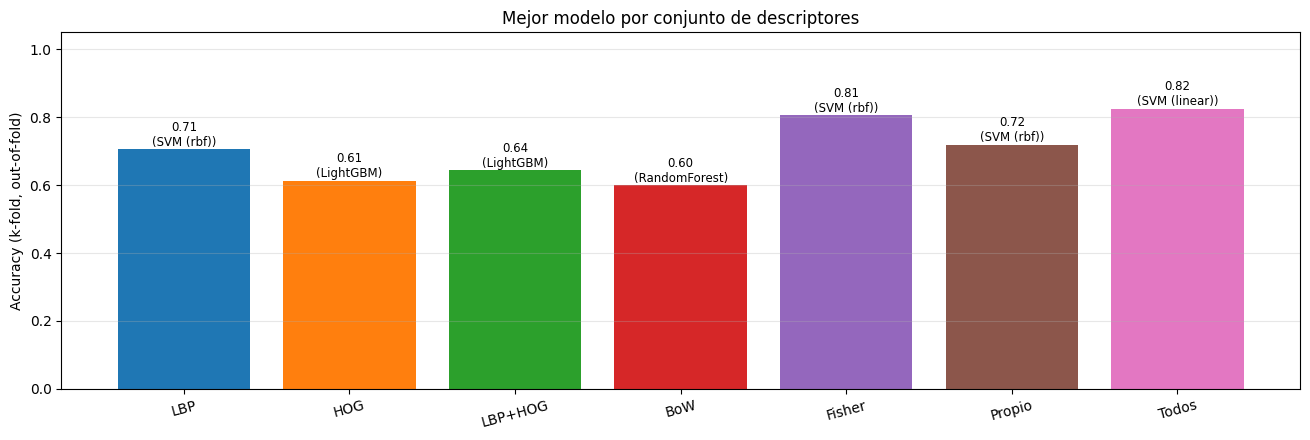

In [3]:
orden_descriptores = list(CONJUNTOS_DESCRIPTORES.keys())
mejor_por_descriptor = (tabla_resultados.sort_values("accuracy", ascending=False)
                                        .groupby("descriptor").first()
                                        .reindex(orden_descriptores))

fig, ax = plt.subplots(figsize=(1.6 * len(orden_descriptores) + 2, 4.5))
colores = plt.cm.tab10.colors
ax.bar(mejor_por_descriptor.index, mejor_por_descriptor["accuracy"],
       color=[colores[i % len(colores)] for i in range(len(mejor_por_descriptor))])
for i, (acc, modelo) in enumerate(zip(mejor_por_descriptor["accuracy"], mejor_por_descriptor["modelo"])):
    ax.text(i, acc + 0.01, f"{acc:.2f}\n({modelo})", ha="center", fontsize=8.5)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy (k-fold, out-of-fold)")
ax.set_title("Mejor modelo por conjunto de descriptores")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
guardar("07_comparacion_descriptores.png")
plt.show()

guardado: figs/08_matriz_confusion_mejor_modelo.png


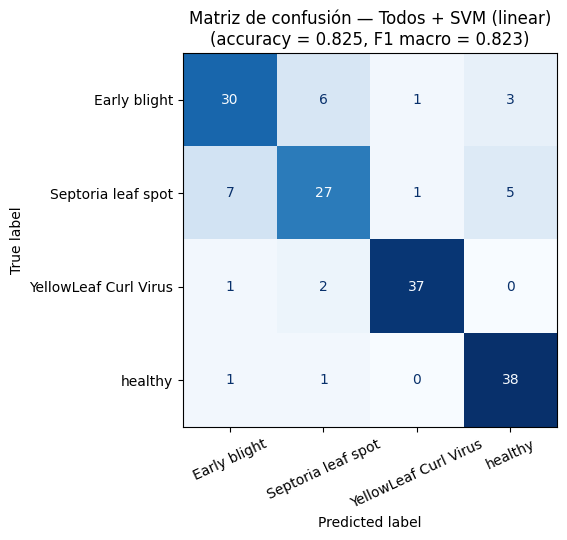

  Early blight             F1 = 0.759
  Septoria leaf spot       F1 = 0.711
  YellowLeaf Curl Virus    F1 = 0.937
  healthy                  F1 = 0.884


In [4]:
mejor_global = next(r for r in RESULTADOS
                     if r["descriptor"] == tabla_resultados.iloc[0]["descriptor"]
                     and r["modelo"] == tabla_resultados.iloc[0]["modelo"])

clases_orden = list(le.classes_) if mejor_global["modelo"] == "XGBoost" else sorted(set(y))
etiquetas_cortas = [etiqueta_corta(c) for c in clases_orden]

disp = ConfusionMatrixDisplay(confusion_matrix=mejor_global["cm"], display_labels=etiquetas_cortas)
fig, ax = plt.subplots(figsize=(6, 5.5))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=25, colorbar=False)
ax.set_title(f"Matriz de confusión — {tabla_resultados.iloc[0]['descriptor']} "
             f"+ {tabla_resultados.iloc[0]['modelo']}\n"
             f"(accuracy = {mejor_global['accuracy']:.3f}, F1 macro = {mejor_global['f1_macro']:.3f})")
plt.tight_layout()
guardar("08_matriz_confusion_mejor_modelo.png")
plt.show()

for c in clases_orden:
    key = str(c)
    if key in mejor_global["reporte"]:
        print(f"  {etiqueta_corta(c):<24} F1 = {mejor_global['reporte'][key]['f1-score']:.3f}")

## 9. Conclusiones

El mejor resultado global lo da el conjunto **"Todos"** (BoW + Fisher + Propio +
LBP+HOG concatenados) con **SVM (kernel lineal)**: accuracy = 0.825, F1 macro =
0.823 en validación k-fold (k=5, out-of-fold). Es decir, combinar todos los
descriptores ayuda, y esto se puede ver porque del top 10, 5 son del conjunto "Todos", el resto de fisher. Pero el salto más grande ya lo da el descriptor Fisher por
sí solo (accuracy ≈ 0.81): captura mucha de la información relevante para
distinguir las 4 clases incluso sin combinarlo con nada más.

LBP+HOG combinados no superan a Fisher ni a "Todos", y de hecho rinden peor que
Fisher solo para este dataset, la textura+forma que capturan LBP/HOG no
alcanza para separar bien las clases más parecidas visualmente. BoW es
consistentemente el descriptor más débil de los seis: al ser un histograma de
"palabras visuales" sin información espacial, pierde detalle que sí aportan
Fisher que guarda momentos de primer y segundo orden por cada palabra visual, o sea mas detalle, o como el descriptor propio que usa directamente color e info de textura o forma de la lesión.

Ahora, sobre los modelos, SVM lineal es consistentemente el mejor o de los mejores en
los conjuntos de más dimensiones (Fisher, "Todos"). De ahí, Random Forest queda
detrás de SVM pero es el mejor de los tres modelos de árboles conaccuracy 0.756
en "Todos". XGBoost y LightGBM rinden por debajo de Random Forest en este
dataset con 0.694 y 0.713 respectivamente en su mejor caso.

La matriz de confusión del mejor modelo muestra que casi todo el error se
concentra entre **Early blight** y **Septoria leaf spot**: son las dos clases
que más se confunden entre sí, algo esperable porque ambas son manchas
necróticas de tono marrón/oscuro sobre la hoja, visualmente parecidas incluso
para el ojo humano. Las otras dos clases hoja sana y virus del rizado amarillo se distinguen mucho mejor, porque tienen un patrón de color y forma
más distintivo, o sea la sana tiene su hoja uniforme sana vs. hojas rizadas y amarillentas, que lo hace mucho mas obvio.

FFinalmente, respecto a las limitaciones, los resultados vienen de un subconjunto local del dataset
PlantVillage (4 clases de tomate), no de las ~15 clases completas del dataset
original, así que estos números no se pueden comparar directamente con
benchmarks publicados sobre PlantVillage completo. Tampoco hice búsqueda de
hiperparámetros, esto porque considere que el objetivo del proyecto no es hallar el mejor modelo, simplemente demostrar que los descriptores, pues funcionan
así que hay margen para mejorar accuracy ajustando, por ejemplo, `C`/`gamma`
en SVM o la profundidad de los árboles tambien. 